In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None)
ALL_SPECTRA = ALL_SPECTRA.subtype_filter(subtype='QSO', exclude=True)

In [4]:
DP = DP()
dp_parent, _, _, _ = DP.extract_fits_data('./catalogs/all_catalog.fits')
dp_sample, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dp_catalog.fits')
dp_sample.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.451893,-78.319199,50.218773,30.572901,...,1,6,9,4,7,0,2,5,8,1
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,112.483803,-62.245144,42.930370,68.479820,...,4,2,9,8,3,0,1,5,7,1
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.860611,-27.739218,29.598230,52.082478,...,1,4,9,7,8,0,2,5,6,1
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,80.845169,-86.188843,52.286289,59.410812,...,6,2,9,8,4,0,1,3,5,2
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,88.226196,-73.512642,38.063850,50.911797,...,2,4,9,8,6,0,1,5,7,3


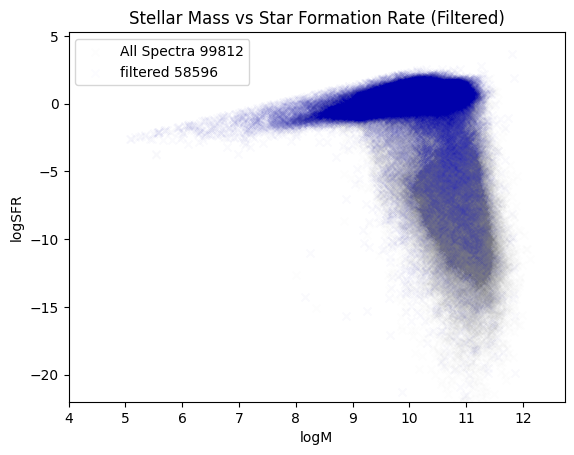

In [13]:
plt.scatter(ALL_SPECTRA.df['LOGM'], ALL_SPECTRA.df['LOGSFR'], color='gray', alpha=0.01, label=f'All Spectra {len(ALL_SPECTRA.df)}', marker='x')
plt.scatter(dp_parent['LOGM'], dp_parent['LOGSFR'], color='blue', alpha=0.01, label=f'filtered {len(dp_parent)}', marker='x')
plt.xlabel('logM')
plt.ylabel('logSFR')
plt.xlim(left=4)
plt.ylim(bottom=-22)
plt.title('Stellar Mass vs Star Formation Rate (Filtered)')
plt.legend()
plt.show()

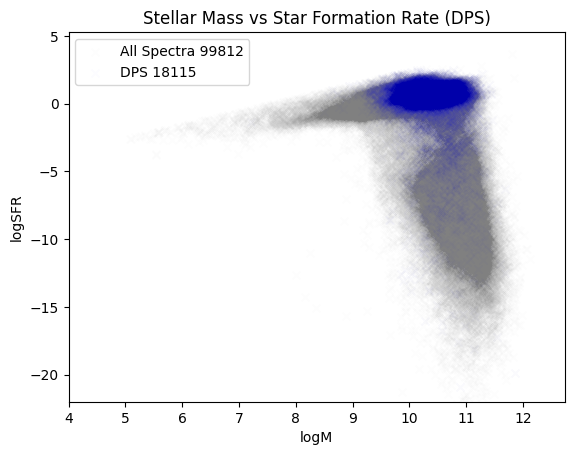

In [14]:
plt.scatter(ALL_SPECTRA.df['LOGM'], ALL_SPECTRA.df['LOGSFR'], color='gray', alpha=0.01, label=f'All Spectra {len(ALL_SPECTRA.df)}', marker='x')
plt.scatter(dp_sample['LOGM'], dp_sample['LOGSFR'], color='blue', alpha=0.01, label=f'DPS {len(dp_sample)}', marker='x')
plt.xlabel('logM')
plt.ylabel('logSFR')
plt.xlim(left=4)
plt.ylim(bottom=-22)
plt.title('Stellar Mass vs Star Formation Rate (DPS)')
plt.legend()
plt.show()

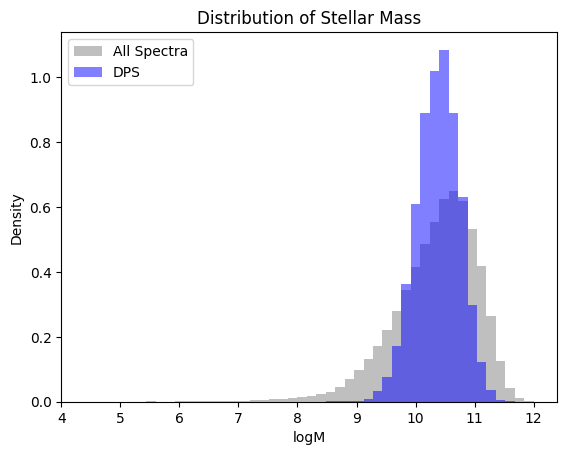

In [21]:
plt.hist(ALL_SPECTRA.df['LOGM'], bins=50, color='gray', alpha=0.5, label='All Spectra', density=True, range=(4, 12))
plt.hist(dp_sample['LOGM'], bins=50, color='blue', alpha=0.5, label='DPS', density=True, range=(4, 12))
plt.xlabel('logM')
plt.ylabel('Density')
plt.xlim(left=4)
plt.title('Distribution of Stellar Mass')
plt.legend()
plt.show()

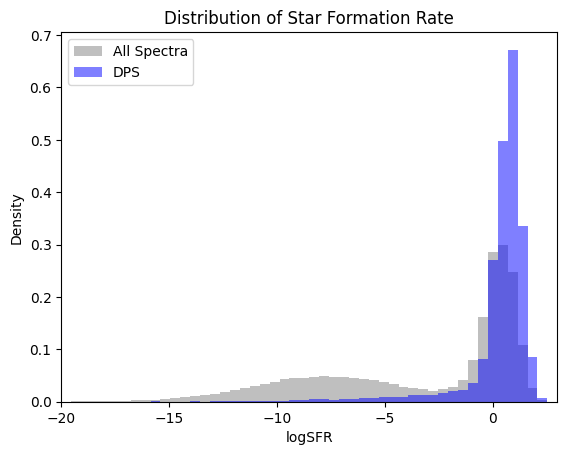

In [22]:
plt.hist(ALL_SPECTRA.df['LOGSFR'], bins=50, color='gray', alpha=0.5, label='All Spectra', density=True, range=(-20, 3))
plt.hist(dp_sample['LOGSFR'], bins=50, color='blue', alpha=0.5, label='DPS', density=True, range=(-20, 3))
plt.xlabel('logSFR')
plt.ylabel('Density')
plt.xlim(left=-20, right=3)
plt.title('Distribution of Star Formation Rate')
plt.legend()
plt.show()

In [23]:
delta_dv = dp_sample['dv_r'] - dp_sample['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+dp_sample['Z']))
sigma_r = np.sqrt(dp_sample['sigma_r']**2 + resolution**2)
sigma_l = np.sqrt(dp_sample['sigma_l']**2 + resolution**2)

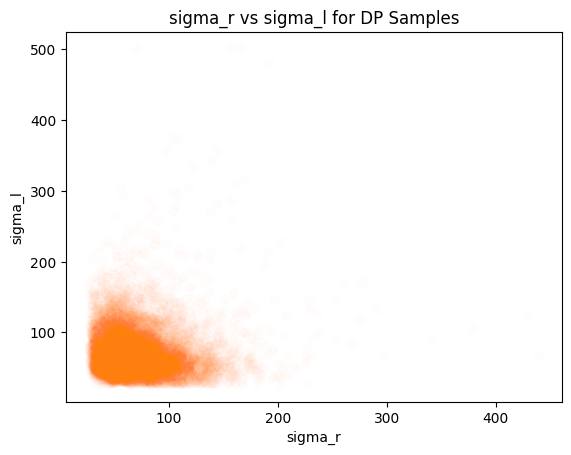

In [30]:
plt.scatter(sigma_r, sigma_l, alpha=.01, color='C1')
plt.xlabel('sigma_r')
plt.ylabel('sigma_l')
plt.title('sigma_r vs sigma_l for DP Samples')
# plt.xlim(left=30)
# plt.ylim(bottom=30)
# plt.legend()
plt.show()

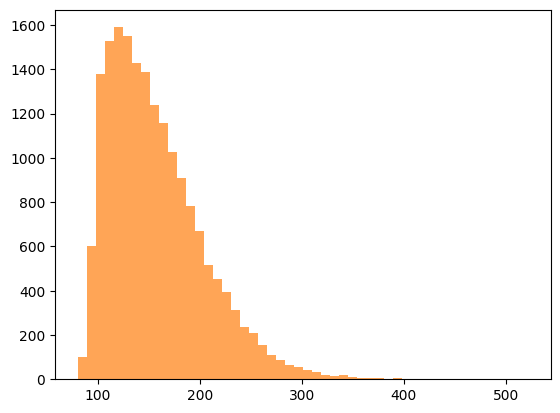

In [31]:
plt.hist(delta_dv, bins=50, color='C1', alpha=0.7)
plt.show()

In [26]:
print(np.mean(delta_dv))
print(np.mean(sigma_r/sigma_l))

156.64447
1.1241258581088722


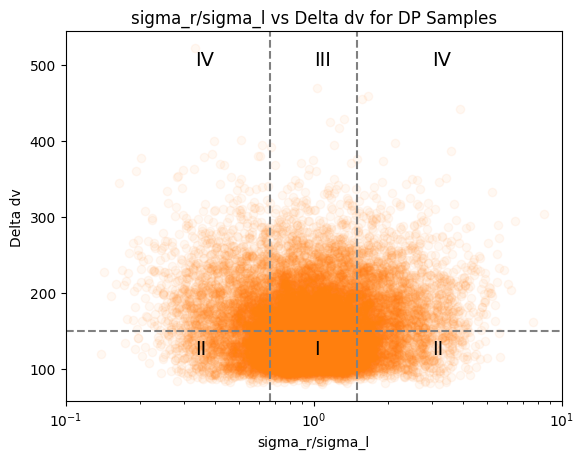

In [34]:
plt.scatter(sigma_r/sigma_l, delta_dv, alpha=.05, color='C1')


plt.text(1, 120, 'I', fontsize=14)
plt.text(1/3, 120, 'II', fontsize=14)
plt.text(3, 120, 'II', fontsize=14)
plt.text(1, 500, 'III', fontsize=14)
plt.text(1/3, 500, 'IV', fontsize=14)
plt.text(3, 500, 'IV', fontsize=14)

plt.axvline(1.5, color='gray', linestyle='--')
plt.axvline(1/1.5, color='gray', linestyle='--')
plt.axhline(150, color='gray', linestyle='--')
plt.xlabel('sigma_r/sigma_l')
plt.ylabel('Delta dv')
plt.title('sigma_r/sigma_l vs Delta dv for DP Samples')
plt.xlim(left=0.1, right=10)
# plt.ylim(bottom=75)
# plt.legend()
plt.xscale('log')
# plt.ylim([0, 500])

plt.show()